In [29]:
import numpy as np
import pandas as pd

In [30]:
df=pd.read_csv("house_data.csv")
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [31]:
df.isnull().sum()


date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

In [32]:
df = pd.get_dummies(df, drop_first=True)


In [33]:
x=df.drop("price",axis=1)
y=df["price"]

In [34]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [35]:
from sklearn.tree import DecisionTreeRegressor
reg=DecisionTreeRegressor(random_state=42)
reg.fit(x_train,y_train)

DecisionTreeRegressor(random_state=42)

In [36]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(x_train,y_train)

RandomForestRegressor(random_state=42)

In [37]:
from sklearn.metrics import *
y_pred_dec=reg.predict(x_test)
y_pred_ran=rf.predict(x_test)


print("decision tree")
print("MSE:",mean_squared_error(y_test,y_pred_dec))
print("R2:",r2_score(y_test,y_pred_dec))


print("random tree")
print("MSE:",mean_squared_error(y_test,y_pred_ran))
print("R2:",r2_score(y_test,y_pred_ran))

decision tree
MSE: 998562589939.1211
R2: 0.02086956565046738
random tree
MSE: 970593368388.0422
R2: 0.04829450257644985


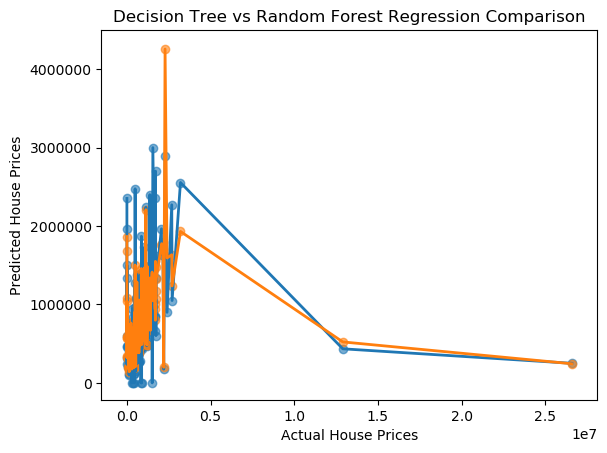

In [38]:
# Sort values for smooth line plotting
import matplotlib.pyplot as plt
sorted_index = np.argsort(y_test.values)

y_test_sorted = y_test.values[sorted_index]
dt_pred_sorted = y_pred_dec[sorted_index]
rf_pred_sorted = y_pred_ran[sorted_index]

plt.figure()

# Scatter points (actual vs predicted)
plt.scatter(y_test, y_pred_dec, alpha=0.6)
plt.scatter(y_test, y_pred_ran, alpha=0.6)

# Prediction lines
plt.plot(y_test_sorted, dt_pred_sorted, linewidth=2)
plt.plot(y_test_sorted, rf_pred_sorted, linewidth=2)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Decision Tree vs Random Forest Regression Comparison")

plt.show()